# 05. Production Simulation Sample Results

### AAI-590 Group 9: Tyler Clinscales, Edwin Merchan, Geoffrey Fadera
---

    This notebook shows a few example results of our production simulation
        1. Object detection is simulated by mapping the preprocessed sample image back to its original image file, and use the available bounding box annotation to draw the bbox around the preprocessed sample. 
        2. this notebook uses the saved prediction output csv files generated during 04 notebook execution.
     
---


In [1]:
import pandas as pd
import os
from random import randint
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import sys
import subprocess

def get_repo_root():
    return subprocess.check_output(['git', 'rev-parse', '--show-toplevel']).decode('utf-8').strip()
repo_root = get_repo_root()
print(repo_root)

src_path = os.path.join(repo_root, 'src')
# Add src_path to sys.path if not already present
if src_path not in sys.path:
    sys.path.insert(0, repo_root)
    sys.path.insert(0, src_path)

import utils.utils as utils

/Users/geoffreyfadera/Documents/USD Stuff/AAI-590/Wild-Scan


In [2]:
# load the model prediction results on the update interval ending in year-month "2013-02", 
# this model is the most recently trained model  prior to this interval
prev_model_inloc_preds_df = pd.read_csv("./production/historical_yearly/production_results_2013-02/prev_model_inloc_preds.csv")
tmp_df = prev_model_inloc_preds_df.copy()
# rretain columns filename, label, bbox, image_id, year_month, pred_label, orig_confidence, calibrated_confidence, uncertainty_mask
tmp_df = tmp_df[['filename', 'bbox', 'image_id', 'year_month', 'label', 'pred_label', 'orig_confidence', 'calibrated_confidence', 'uncertainty_mask']]
tmp_df = tmp_df[tmp_df['label'] != tmp_df['pred_label']]
tmp_df.reset_index(inplace=True, drop=True)
tmp_df.head()

# set original images path
eccv18_imgs_path = "/Users/geoffreyfadera/Documents/USD Stuff/AAI-540/Module7/TeamProject/eccv_18_all_images_sm"

--- 
## Example # 1

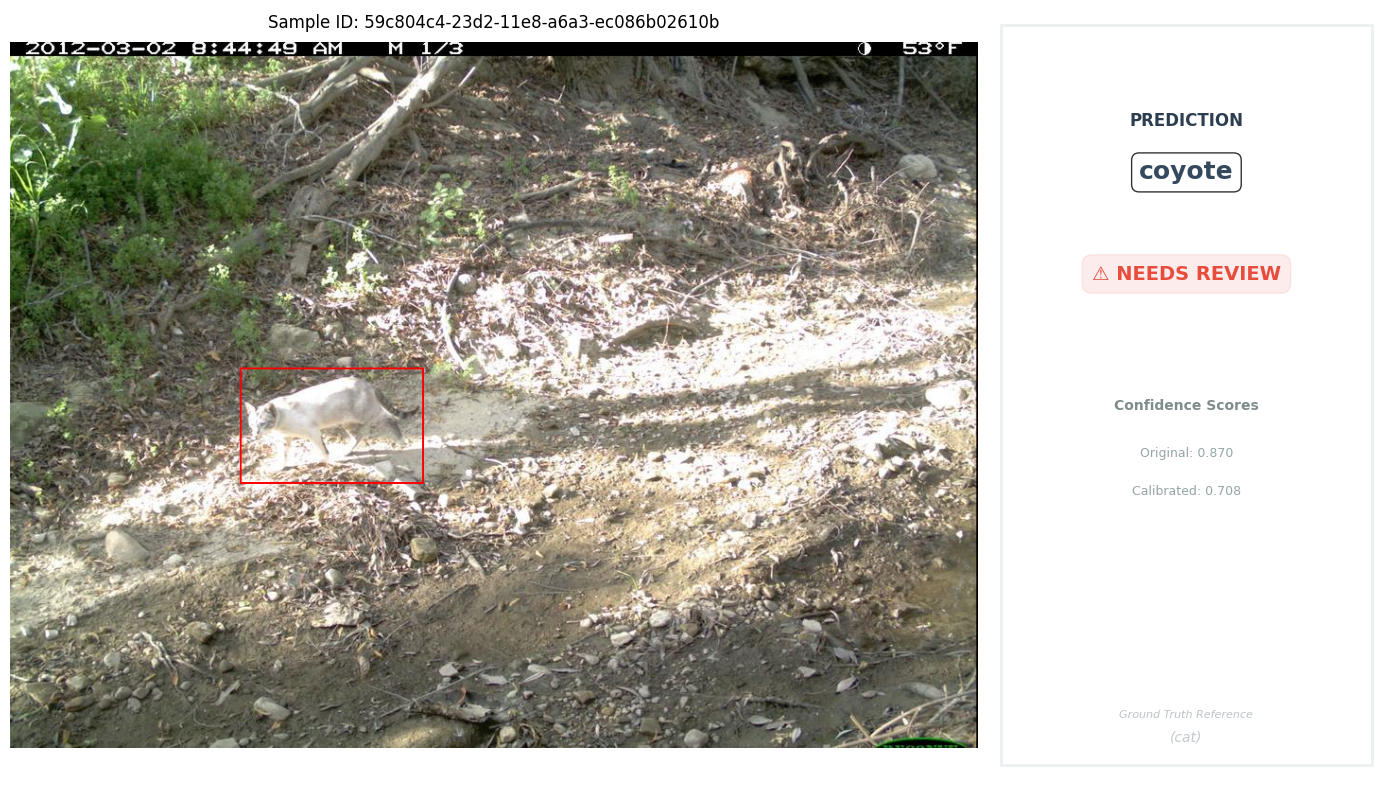

In [3]:
id = 13  # or any other index
fig = utils.display_image_with_info(tmp_df, id, eccv18_imgs_path)
plt.show()

## Analysis:
### On this image, the image classifier trained before this time interval is confident (0.87) that this is a "coyote". However, with TvA Calibration, the confidence is reduced to 0.708. The confidence threshold for this predictions file was set to 0.8. This allowed our pipeline to flag this prediction as uncertain and needs human review.


---
## Other Examples
(randomly chosen from the predictions file)


--- Sample 1/10 ---


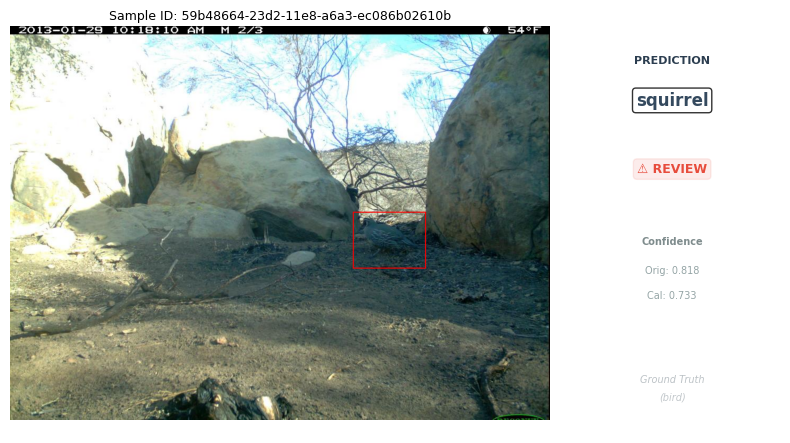


--- Sample 2/10 ---


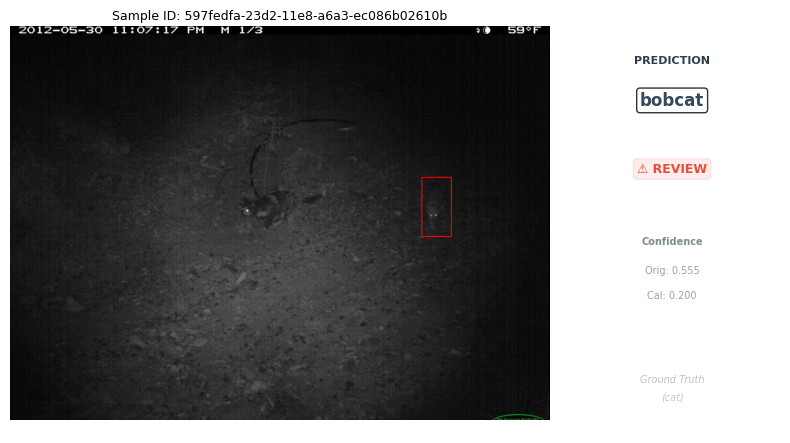


--- Sample 3/10 ---
Image not found: /Users/geoffreyfadera/Documents/USD Stuff/AAI-540/Module7/TeamProject/eccv_18_all_images_sm/5a07cf1f-23d2-11e8-a6a3-ec086b02610b.jpg

--- Sample 4/10 ---
Image not found: /Users/geoffreyfadera/Documents/USD Stuff/AAI-540/Module7/TeamProject/eccv_18_all_images_sm/597e6233-23d2-11e8-a6a3-ec086b02610b.jpg

--- Sample 5/10 ---


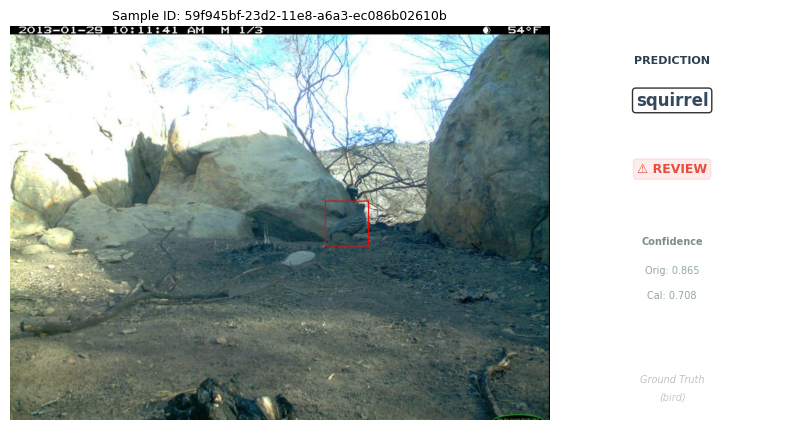


--- Sample 6/10 ---


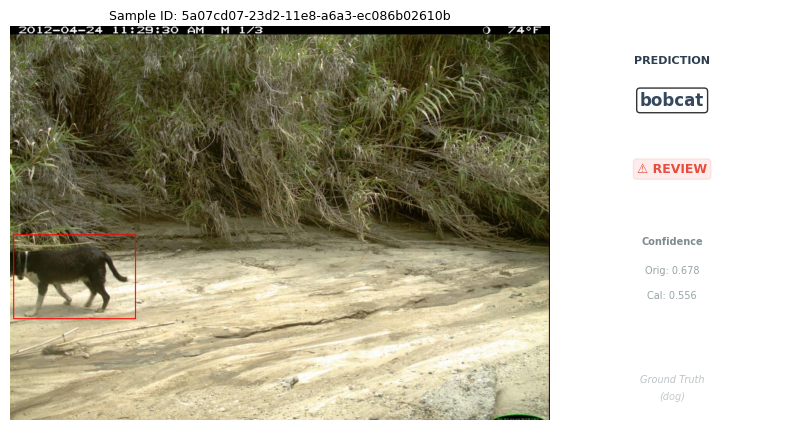


--- Sample 7/10 ---
Image not found: /Users/geoffreyfadera/Documents/USD Stuff/AAI-540/Module7/TeamProject/eccv_18_all_images_sm/5a0c9c11-23d2-11e8-a6a3-ec086b02610b.jpg

--- Sample 8/10 ---


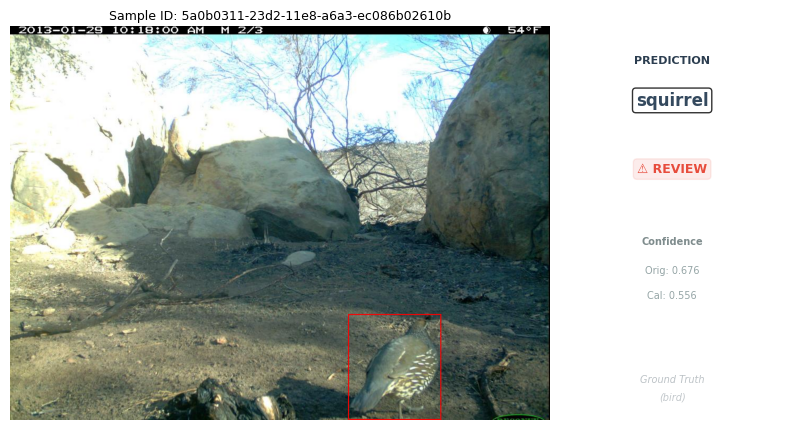


--- Sample 9/10 ---


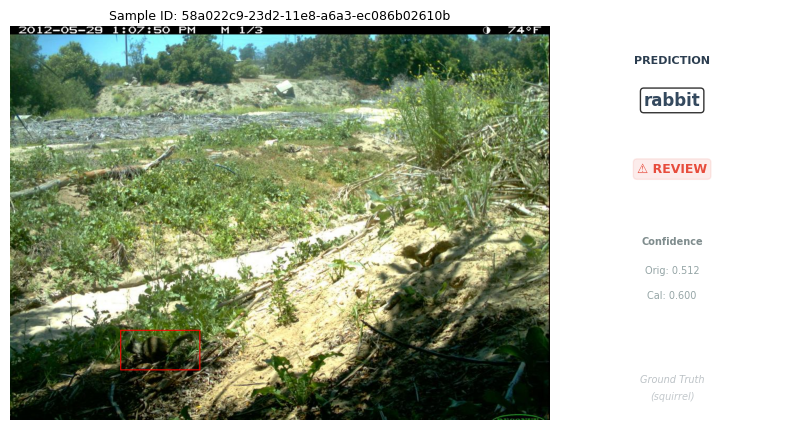


--- Sample 10/10 ---


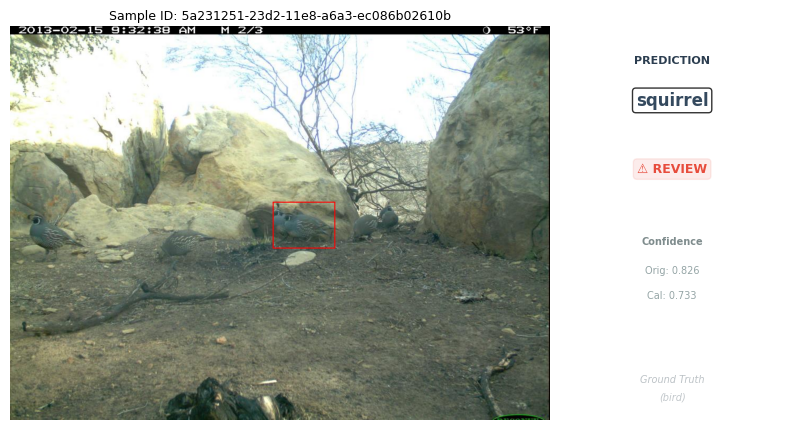


--- Sample 11/10 ---


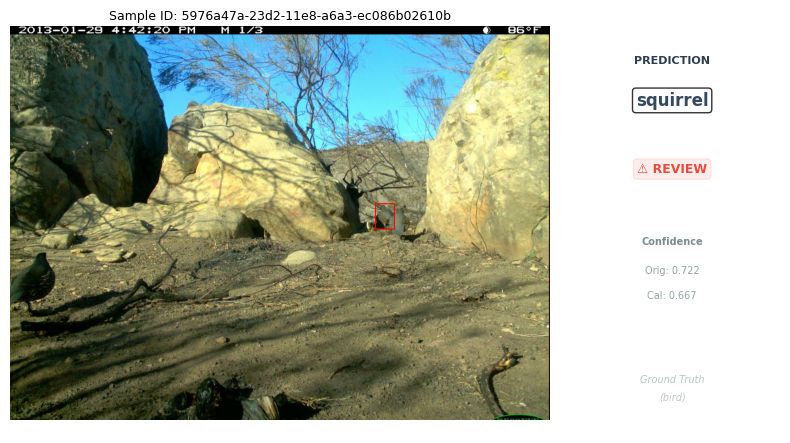


--- Sample 12/10 ---


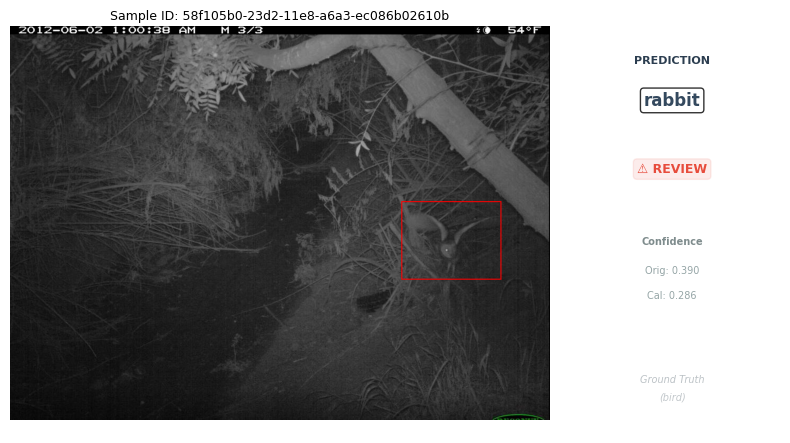


--- Sample 13/10 ---


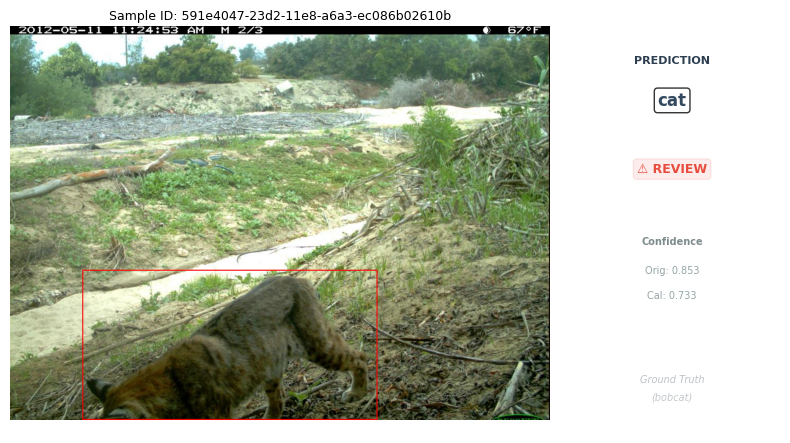


--- Sample 14/10 ---
Image not found: /Users/geoffreyfadera/Documents/USD Stuff/AAI-540/Module7/TeamProject/eccv_18_all_images_sm/59b48436-23d2-11e8-a6a3-ec086b02610b.jpg

--- Sample 15/10 ---


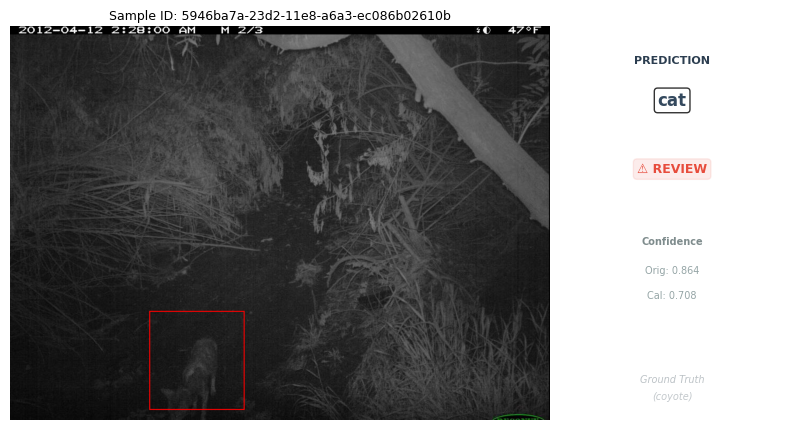


--- Sample 16/10 ---


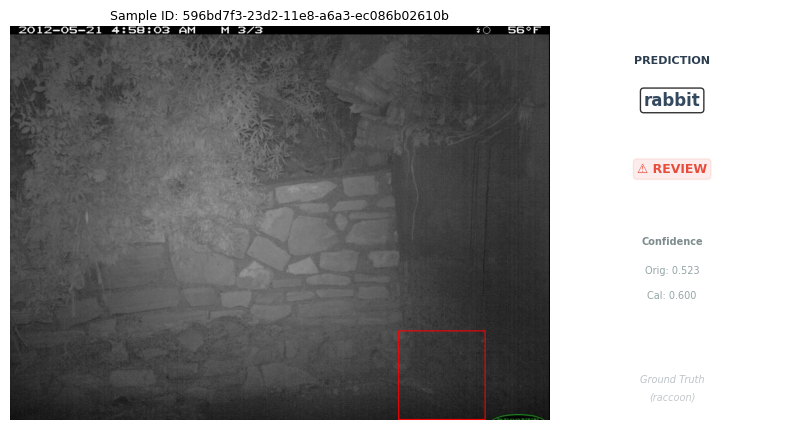


--- Sample 17/10 ---


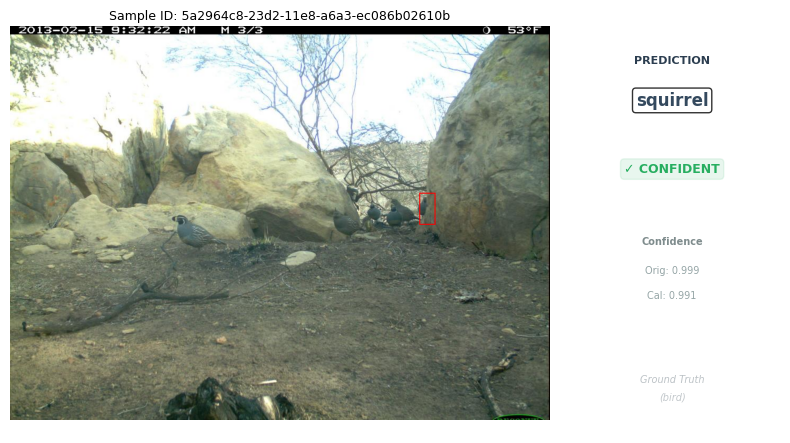


--- Sample 18/10 ---


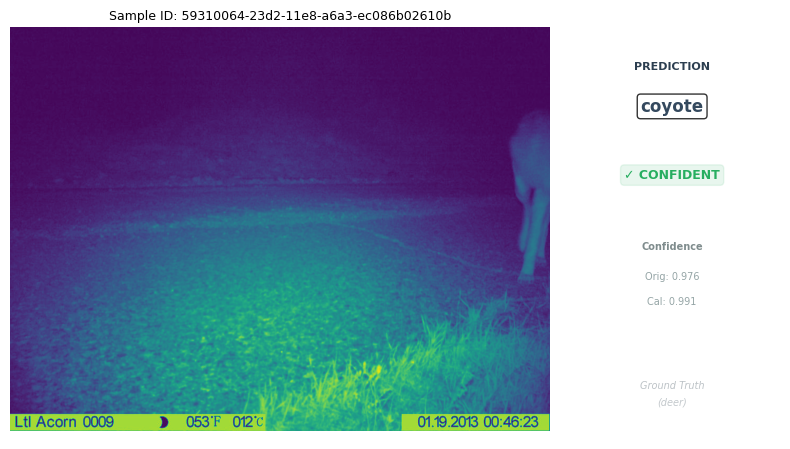


--- Sample 19/10 ---


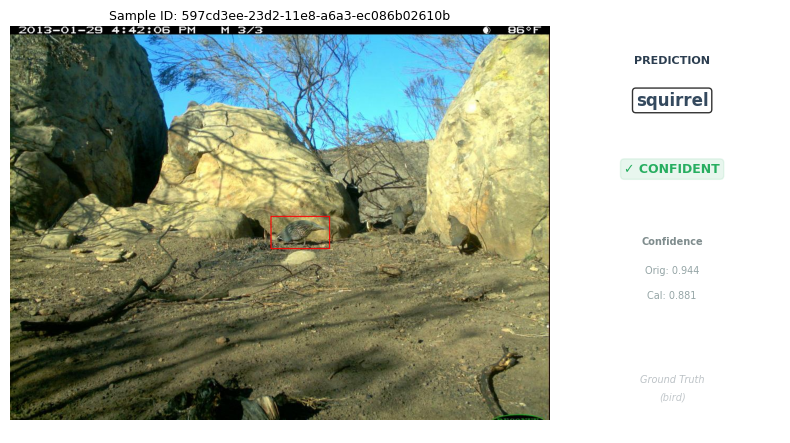


--- Sample 20/10 ---
Image not found: /Users/geoffreyfadera/Documents/USD Stuff/AAI-540/Module7/TeamProject/eccv_18_all_images_sm/59641cb1-23d2-11e8-a6a3-ec086b02610b.jpg


In [4]:
random_indices = np.random.choice(len(tmp_df), 20, replace=False)

for i, idx in enumerate(random_indices):
    print(f"\n--- Sample {i+1}/10 ---")
    fig = utils.display_image_with_info_compact(tmp_df, idx, eccv18_imgs_path)
    if fig is not None:
        plt.show()
    else:
        del fig

---
## Final Note:
        1. The predictions above are by a model trained in  the previous time interval.
        2. With Active Learning using Calibration and Confidence thresholding, our ml_system is able identify uncertain predictions that need human attention, therefore reducing human effort.
        
